# 📘 Linear Regression

## 🔹 Introduction
Linear Regression is one of the simplest and most widely used algorithms in **supervised machine learning**.
It is used to model the relationship between a **dependent variable (target)** and one or more **independent variables (features)**.

The main idea is to find the **best-fit straight line** through the data points.

---

## 🔹 Equation of Linear Regression
For a **single variable (Simple Linear Regression)**, the equation is:

$$
y = mx + b
$$

- $y$: Dependent variable (output / target)
- $x$: Independent variable (input / feature)
- $m$: Slope of the line (weight/parameter)
- $b$: Intercept (bias/constant term)

---

## 🔹 Derivation of $m$ and $b$ (Least Squares Method)
The goal is to minimize the error (difference between actual and predicted values).
Using calculus, the formulas for slope and intercept are derived as:

$$
m = \frac{ n \sum (x_i y_i) - \sum x_i \sum y_i }{ n \sum (x_i^2) - (\sum x_i)^2 }
$$

$$
b = \frac{ \sum y_i - m \sum x_i }{ n }
$$

where:
- $n$ = number of data points
- $(x_i, y_i)$ = data points

---

## 🔹 Cost Function
The **error** is measured using the **Mean Squared Error (MSE):**

$$
J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y_i})^2
$$

where $\hat{y_i} = mx_i + b$.

---

## 🔹 Assumptions of Linear Regression
1. **Linearity** – The relationship between input and output is linear.
2. **Independence** – Data points are independent.
3. **Homoscedasticity** – Constant variance of errors.
4. **Normality of errors** – Errors are normally distributed.

---

## 🔹 Advantages
- Simple and easy to understand.
- Works well for linearly separable data.
- Fast and computationally inexpensive.

---

## 🔹 Disadvantages
- Assumes linearity (does not work well for non-linear data).
- Sensitive to outliers.
- Limited in capturing complex relationships.

---

## 🔹 Applications
- Predicting house prices based on area, location, etc.
- Estimating sales based on advertising expenditure.
- Predicting student performance based on study hours.
- Stock market trend prediction (basic level).

---

✅ **In summary:**
Linear Regression is a **fundamental regression technique** that models relationships using a straight line.
The parameters $m$ (slope) and $b$ (intercept) are calculated using the **least squares method** to minimize error.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


In [2]:
data = pd.read_csv('E:\python\placement.csv')
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


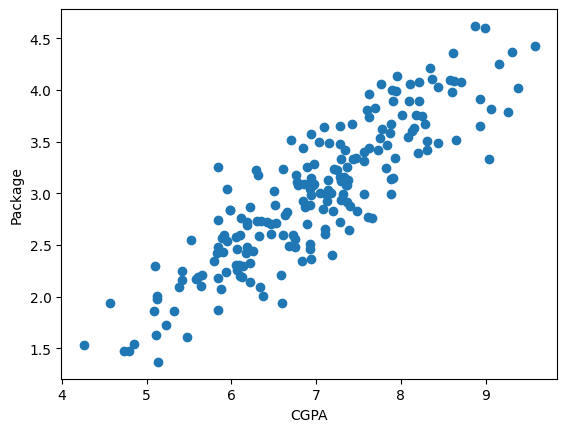

In [5]:
plt.scatter(data['cgpa'], data['package'])
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.show()

In [11]:
x = data.iloc[:, :1]
y = data.iloc[:, 1:2]

In [16]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.1, random_state=2)

In [18]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [19]:
X_test

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57
85,4.79
10,5.32
54,6.86
115,8.35
35,6.87


In [20]:
lr.score(X_test, Y_test)

0.8510662353930815

In [27]:
lr.predict(X_test.iloc[0].values.reshape(1,1))

D:\mlenv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[3.8934864]])

In [28]:
Y_test.iloc[0].values.reshape(1,1)

array([[4.1]])

Text(0, 0.5, 'Package')

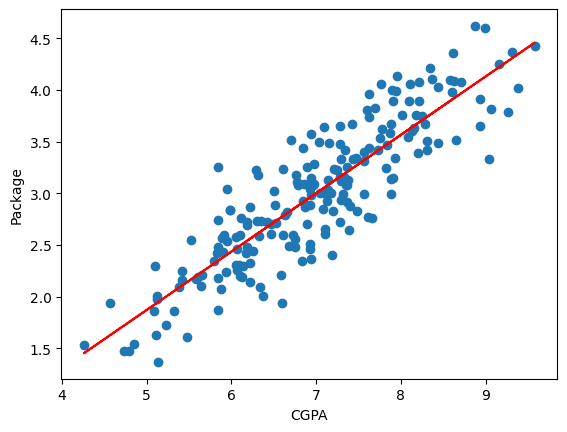

In [29]:
plt.scatter(data['cgpa'], data['package'])
plt.plot(X_train, lr.predict(X_train), color='red')
plt.xlabel('CGPA')
plt.ylabel('Package')


In [30]:
m = lr.coef_

In [31]:
m

array([[0.56476918]])

In [32]:
b = lr.intercept_

In [33]:
b

array([-0.95223314])

In [34]:
m * 100 + b

array([[55.52468462]])

In [35]:
m * 10 + b

array([[4.69545864]])

In [52]:
class DibyaLR:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, x, y):
        num =0
        den =0

        for i in range( x.shape[0]):
            num += ((x[i] - x.mean()) * (y[i] - y.mean()))
            den += (x[i] - x.mean()) ** 2

        self.m = num / den
        self.b = y.mean() - ( self.m * x.mean())
        print(self.m, self.b)
        return self

    def predict(self, test):
        print(test)
        return self.m * test + self.b

    def error(self, x, y):
        y_pred = self.predict(x)
        mse = ((y - y_pred) ** 2).mean()
        print("Mean Squared Error:", mse)
        return mse

In [53]:
newlr = DibyaLR()
newlr.fit(x, y)

[0.56959129] [-0.98567795]


In [54]:
newlr.predict(test=10)

10


array([4.710235])

In [57]:
newlr.error(x=10, y=4.710235)

10
Mean Squared Error: 2.8284528432956715e-18


np.float64(2.8284528432956715e-18)

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [59]:
y_pred = lr.predict(X_test)

In [64]:
y_org = Y_test.values

In [65]:
print("MSE:", mean_squared_error(y_org, y_pred))

MSE: 0.09513870266369379


In [66]:
print("MAE:", mean_absolute_error(y_org, y_pred))

MAE: 0.26530089639951643


In [68]:
print("RMSE:", root_mean_squared_error(y_org, y_pred))

RMSE: 0.30844562351197946


In [71]:
print("R^2:", r2_score(y_org, y_pred))
r2 = r2_score(y_org, y_pred)

R^2: 0.8510662353930815


In [74]:
r2Adj = 1 - ((1-r2) * (20-1) / ( 20 -1 -1))

In [70]:
len(Y_test)

20

In [75]:
r2Adj

0.8427921373593638

In [76]:
import numpy as np
newData = data.copy()
newData["iq"] = newData["cgpa"] + ( np.random.randint(-12,12,200) / 10)
newData = newData[["cgpa", "iq","package"]]

In [77]:
newData.head()

,cgpa,iq,package
0,6.89,7.79,3.26
1,5.12,4.32,1.98
2,7.82,8.52,3.25
3,7.42,7.52,3.67
4,6.94,7.24,3.57


Text(0, 0.5, 'IQ')

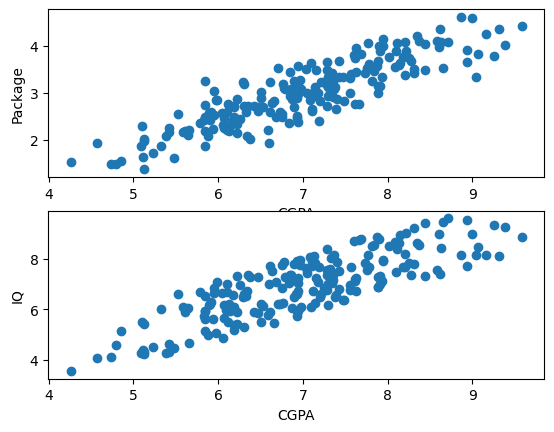

In [78]:
plt.subplot(2,1,1)
plt.scatter(newData["cgpa"], newData["package"])
plt.xlabel('CGPA')
plt.ylabel('Package')
plt.subplot(2,1,2)
plt.scatter(newData["cgpa"], newData["iq"])
plt.xlabel('CGPA')
plt.ylabel('IQ')


In [79]:
new_x = newData.iloc[:, :1]
new_y = newData.iloc[:, 1:2]

In [80]:
new_x_train, new_x_test, new_y_train, new_y_test = train_test_split(new_x, new_y, test_size=0.1, random_state=2)

In [81]:
lr = LinearRegression()
lr.fit(new_x_train, new_y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [82]:
new_y_pred = lr.predict(new_x_test)

In [83]:
print("R^2:", r2_score(new_y_test, new_y_pred))
r2 = r2_score(new_y_test, new_y_pred)

R^2: 0.8041349584697712


In [84]:
r2Adj = 1 - ((1-r2) * (20-1) / ( 20 -1 -2))

In [85]:
r2Adj

0.7810920124073913